In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

df1 = pd.read_excel("retail.xlsx")
df1.head()
df2=pd.read_excel('retail.xlsx')
df2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df2 = df2.dropna(subset=['Customer ID'])

In [7]:
df2.shape

(417534, 8)

In [8]:
df2.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [12]:
#as here we can see that description is a categorical column we have to replace the null with mode value

In [9]:
df1["Description"]=df1["Description"].fillna(df1["Description"].mode()[0])

In [10]:
df1.isna().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [18]:
#now we will see the duplicates in our data

In [11]:
df2.duplicated().sum()

np.int64(6771)

In [12]:
df2=df2.drop_duplicates()

In [13]:
df2.duplicated().sum()

np.int64(0)

In [22]:
#as we can see that there are no duplicates in our data , now our data is a bit good for further steps

In [24]:
#NOW WE WILL CHECK THE OUTLIIERS IN OUR DATA FOR SEPERATE COLUMN
#FOR THIS I M GONNA USE MATPLOTLIB LIBRARY

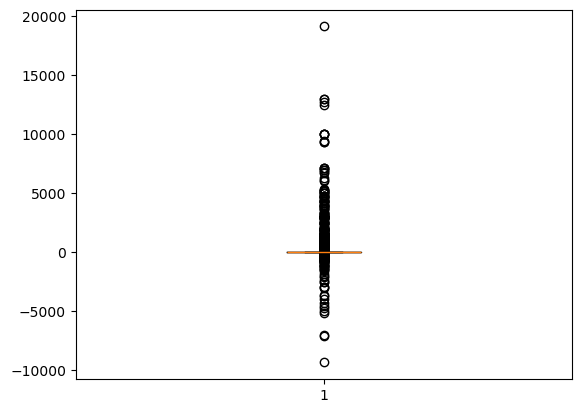

In [14]:
plt.boxplot(df2["Quantity"])
plt.show()

In [15]:
(df2['Quantity'] < 0).sum()

np.int64(9816)

In [16]:
(df2['Quantity'] == 0).sum()

np.int64(0)

In [17]:
(df2['Price'] ==0).sum()

np.int64(31)

In [18]:
(df2['Price'] <=0).sum()

np.int64(31)

In [20]:
((df2["Price"] <= 0).sum() / len(df1)) * 100

np.float64(0.005899581510330929)

In [21]:
df2.sort_values('Quantity', ascending=False).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom
135030,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom
135028,502269,21982,PACK OF 12 SUKI TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom
135029,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom
93677,498152,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,9456,2010-02-17 10:51:00,0.30,13902.0,Denmark


In [22]:
df2[df2["Price"] <= 0].sample(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
392008,527084,22630,DOLLY GIRL LUNCH BOX,64,2010-10-14 15:33:00,0.0,14646.0,Netherlands
248583,513416,22423,REGENCY CAKESTAND 3 TIER,5,2010-06-24 12:34:00,0.0,13089.0,United Kingdom
89180,497843,TEST001,This is a test product.,5,2010-02-12 15:47:00,0.0,14827.0,United Kingdom
512240,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
327801,521375,22202,MILK PAN PINK RETROSPOT,3,2010-09-05 11:58:00,0.0,12647.0,Germany
453705,532470,22624,IVORY KITCHEN SCALES,2,2010-11-12 11:41:00,0.0,12647.0,Germany
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
166143,505083,22376,AIRLINE BAG VINTAGE JET SET WHITE,1,2010-04-20 09:56:00,0.0,12623.0,Germany
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom


In [23]:
df2["Invoice"]

0         489434
1         489434
2         489434
3         489434
4         489434
           ...  
525456    538171
525457    538171
525458    538171
525459    538171
525460    538171
Name: Invoice, Length: 410763, dtype: object

In [24]:
(df2['Quantity'] < 0).sum()

np.int64(9816)

In [25]:
df2['Invoice'] = df2['Invoice'].astype(str)

df2 = df2[~df2['Invoice'].str.startswith('C')]


df2 = df2[df2['Quantity'] > 0]


df2 = df2[df2['Price'] > 0]

In [26]:
df2.shape

(400916, 8)

In [27]:
print("Negative/Zero Quantity:", (df2['Quantity'] <= 0).sum())
print("Negative/Zero Price:", (df2['Price'] <= 0).sum())

Negative/Zero Quantity: 0
Negative/Zero Price: 0


In [57]:
#NOW AFTER PERFORMING ALL THESE , FURTHER STEP IS EATURE ENGINEERING

In [28]:
#CREATING THE REVENUE COLUMN (PRICE * QUANTITY)
df2['Revenue'] = df2['Quantity'] * df2['Price']

In [29]:
df2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [30]:
df_clean = df2.copy()

In [112]:
df_clean.to_csv('new_pbi_data.csv', index=False)

In [31]:
analy_df=df2.copy()

In [32]:
analy_df.shape

(400916, 9)

In [33]:
analy_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [34]:
analy_df['Customer ID'].isnull().sum()

np.int64(0)

In [35]:
analy_df.duplicated().sum()

np.int64(0)

In [36]:
analy_df=analy_df.drop_duplicates()

In [37]:
analy_df.duplicated().sum()

np.int64(0)

In [38]:
analy_df.shape

(400916, 9)

In [114]:
analy_df.to_csv('cleaned_retail_data2.csv', index=False)

In [110]:
#building the R-RECENCY , F-FREQUENCY , M-MONETARY TABLE FOR CUSTOMER CHURN ANALYSIS

In [39]:
monetary = analy_df.groupby('Customer ID')['Revenue'].sum().reset_index()

monetary.columns = ['Customer ID', 'Monetary']

In [40]:
frequency = analy_df.groupby('Customer ID')['Invoice'].nunique().reset_index()

frequency.columns = ['Customer ID', 'Frequency']

In [41]:
reference_date = analy_df['InvoiceDate'].max() + pd.Timedelta(days=1)

recency = analy_df.groupby('Customer ID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (reference_date - recency['InvoiceDate']).dt.days

recency = recency[['Customer ID', 'Recency']]

In [120]:
#MERGING ALL THE THREE RFM 

In [42]:
rfm = recency.merge(frequency, on='Customer ID')
rfm = rfm.merge(monetary, on='Customer ID')

In [43]:
rfm.shape

(4312, 4)

In [44]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [45]:
rfm['Recency'].skew()

np.float64(1.2829281524843608)

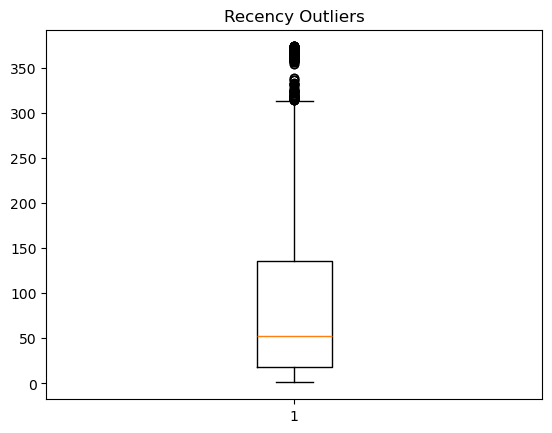

In [46]:
plt.boxplot(rfm['Recency'])
plt.title('Recency Outliers')
plt.show()

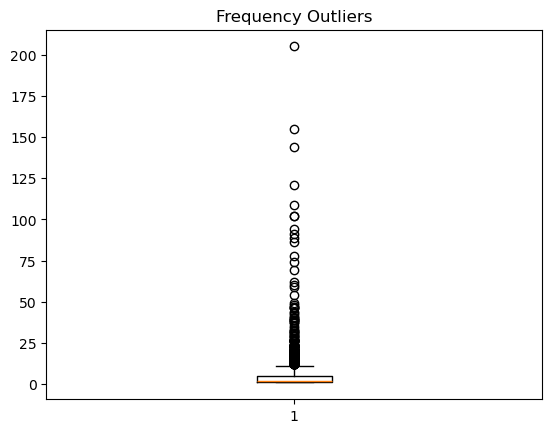

In [47]:
plt.boxplot(rfm['Frequency'])
plt.title('Frequency Outliers')
plt.show()

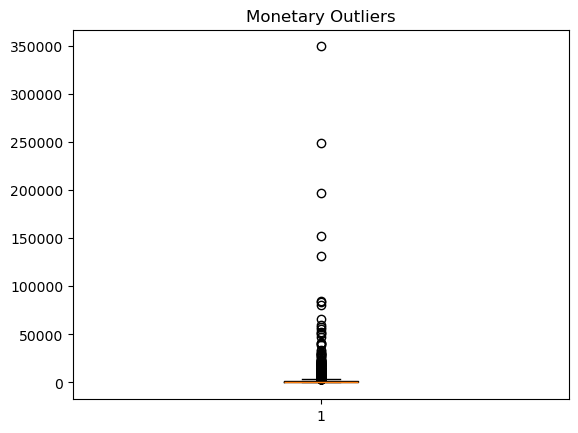

In [48]:
plt.boxplot(rfm['Monetary'])
plt.title('Monetary Outliers')
plt.show()

In [49]:
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = rfm[(rfm['Monetary'] < lower) | (rfm['Monetary'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 423


In [50]:
Q1 = rfm['Recency'].quantile(0.25)
Q3 = rfm['Recency'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = rfm[(rfm['Recency'] < lower) | (rfm['Recency'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 177


In [51]:
Q1 = rfm['Frequency'].quantile(0.25)
Q3 = rfm['Frequency'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = rfm[(rfm['Frequency'] < lower) | (rfm['Frequency'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 285


In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

In [86]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency','Frequency','Monetary']
)

In [87]:
Q1 = rfm_scaled['Monetary'].quantile(0.25)
Q3 = rfm_scaled['Monetary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = rfm_scaled[(rfm_scaled['Monetary'] < lower) | (rfm_scaled['Monetary'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 64


In [101]:
print(rfm[['Recency','Frequency','Monetary']].skew())

Recency     -1.598663
Frequency    0.310074
Monetary    -0.784843
dtype: float64


In [84]:


rfm['Recency'] = np.log1p(rfm['Recency'])
rfm['Frequency'] = np.log1p(rfm['Frequency'])
rfm['Monetary'] = np.log1p(rfm['Monetary'])

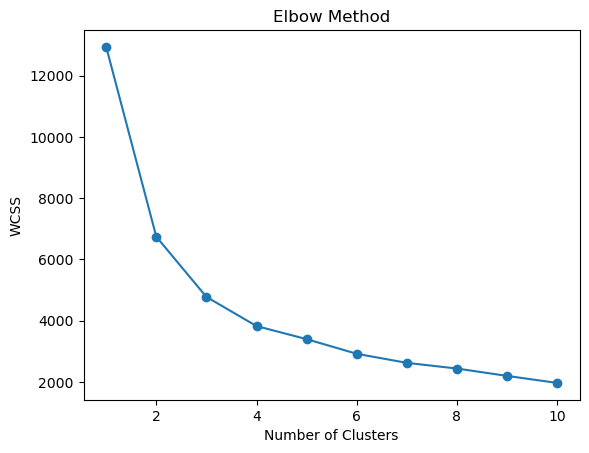

In [89]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [90]:
rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.812745,1.516138,-0.432196
1,-2.166456,-0.253548,0.522180
2,0.441174,-1.164513,-0.891310
3,0.146003,0.239255,0.971358
4,-0.817965,-1.164513,-0.616558


In [91]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [105]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,0.890043,0.751493,1.157216
1,0.995629,0.434329,1.042155
2,0.577480,0.755306,1.152976
3,0.959240,0.589202,1.107986


In [93]:
rfm['Cluster']

0       3
1       2
2       1
3       3
4       1
       ..
4307    0
4308    1
4309    1
4310    3
4311    0
Name: Cluster, Length: 4312, dtype: int32

In [106]:
segment_map = {
    0: 'Loyal Customers',
    1: 'At Risk Customers',
    2: 'VIP Customers',
    3: 'Regular Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

In [107]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,1.033274,0.810237,1.076699,3,Regular Customers
1,12347.0,0.625800,0.554618,1.132289,2,VIP Customers
2,12348.0,0.982453,0.423036,1.049958,1,At Risk Customers
3,12349.0,0.942082,0.625800,1.158452,3,Regular Customers
4,12351.0,0.810237,0.423036,1.065961,1,At Risk Customers


In [108]:
rfm['Segment'].value_counts()

Segment
Regular Customers    1462
At Risk Customers    1435
Loyal Customers      1049
VIP Customers         366
Name: count, dtype: int64

In [109]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(score)

0.33978866897319265


In [110]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.418
K=3, Silhouette Score=0.391
K=4, Silhouette Score=0.340
K=5, Silhouette Score=0.342
K=6, Silhouette Score=0.310
K=7, Silhouette Score=0.297
K=8, Silhouette Score=0.288
K=9, Silhouette Score=0.301
K=10, Silhouette Score=0.309


In [99]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,1.033274,0.810237,1.076699,3,VIP Customers
1,12347.0,0.625800,0.554618,1.132289,2,Loyal Customers
2,12348.0,0.982453,0.423036,1.049958,1,At Risk Customers
3,12349.0,0.942082,0.625800,1.158452,3,VIP Customers
4,12351.0,0.810237,0.423036,1.065961,1,At Risk Customers


In [111]:
rfm.to_csv('rfm_data12.csv', index=False)

In [102]:
rfm[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,0.922113,0.591242,1.101873
std,0.136789,0.144460,0.058253
min,0.423036,0.423036,0.622970
25%,0.863863,0.423036,1.067012
50%,0.958289,0.554618,1.105980
75%,1.021851,0.706395,1.142277
max,1.076849,1.045551,1.287028


In [103]:
print(rfm.head())

   Customer ID   Recency  Frequency  Monetary  Cluster            Segment
0      12346.0  1.033274   0.810237  1.076699        3      VIP Customers
1      12347.0  0.625800   0.554618  1.132289        2    Loyal Customers
2      12348.0  0.982453   0.423036  1.049958        1  At Risk Customers
3      12349.0  0.942082   0.625800  1.158452        3      VIP Customers
4      12351.0  0.810237   0.423036  1.065961        1  At Risk Customers


In [104]:
print(rfm_scaled.head())

    Recency  Frequency  Monetary
0  0.812745   1.516138 -0.432196
1 -2.166456  -0.253548  0.522180
2  0.441174  -1.164513 -0.891310
3  0.146003   0.239255  0.971358
4 -0.817965  -1.164513 -0.616558


In [113]:
# Cleaned transaction data
df2.to_csv("cleaned_transactions_1.csv", index=False)

# RFM data with clusters
rfm.to_csv("customer_rfm_1.csv", index=False)